In [1]:
import warnings

import geopandas as gpd
# import contextily as ctx
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
# from IPython.display import HTML
from matplotlib import animation

import city2graph

warnings.filterwarnings("ignore")

D:\workSoftware\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
poi_tags = {
    "amenity": [
        "restaurant"]}

#poi_gdf = ox.features_from_place("Shibuya, Tokyo, Japan", poi_tags)
poi_gdf = ox.features_from_point(
    (35.658514, 139.70133),  # Tokyo Tower coordinates
    tags=poi_tags,
    dist=1000,  # Search radius in meters
    )

# Filter to include only nodes, not ways and relations
poi_gdf = poi_gdf[poi_gdf.index.get_level_values("element") == "node"]

# Reproject to a projected CRS for accurate centroids
poi_gdf = poi_gdf.to_crs(epsg=6677)

In [3]:
segments_G = ox.graph_from_point(
    (35.658514, 139.70133),  # Tokyo Tower coordinates
    dist=1000,  # Search radius in meters
    )

segments_gdf = ox.graph_to_gdfs(segments_G, nodes=False, edges=True)

In [4]:
def get_node_positions(gdf):
    """Extract node positions from GeoDataFrame."""
    node_positions = {}
    for id, geom in gdf["geometry"].items():
        if geom.geom_type == "Point":
            node_positions[id] = (geom.x, geom.y)
        else:
            centroid = geom.centroid
            node_positions[id] = (centroid.x, centroid.y)
    return node_positions

def plot_graph(graph,
               title,
               node_positions,
               add_basemap=False,
               crs=None):
    """Plot a network graph with color-coded nodes based on degree centrality."""
    # Compute degree centrality for node coloring
    node_degrees = dict(graph.degree())
    node_colors = [node_degrees.get(node, 0) for node in graph.nodes()]

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))

    # Set equal aspect ratio to maintain map proportions
    ax.set_aspect("equal")

    # Plot the edges with better color
    nx.draw_networkx_edges(graph, pos=node_positions,
                          edge_color="grey",
                          alpha=0.5,
                          width=0.5,
                          ax=ax)

    # Plot the POIs with beautiful color scheme
    nodes = nx.draw_networkx_nodes(graph, pos=node_positions,
                          node_size=30,
                          node_color=node_colors,
                          cmap=plt.cm.plasma,
                          alpha=0.9,
                          linewidths=0.5,
                          ax=ax)

    # Add basemap if requested - with no buffer/margin
    # if add_basemap and crs:
    #     ctx.add_basemap(ax, crs=crs, source=ctx.providers.CartoDB.Positron)

    # Set exact limits based on node positions to avoid any buffer
    node_xs = [pos[0] for pos in node_positions.values()]
    node_ys = [pos[1] for pos in node_positions.values()]
    ax.set_xlim(min(node_xs), max(node_xs))
    ax.set_ylim(min(node_ys), max(node_ys))

    # Add a colorbar with better styling
    cbar = plt.colorbar(nodes, ax=ax, label="Degree Centrality", shrink=0.8)
    cbar.ax.tick_params(labelsize=10)

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

node_positions = get_node_positions(poi_gdf)

创建一个交互式滑块，用于绘制不同k值下的KNN图

In [5]:
knn_l1_nodes, knn_l1_edges = city2graph.knn_graph(poi_gdf,
                              distance_metric="manhattan",
                              network_gdf=segments_gdf.to_crs(epsg=6677))

knn_l2_nodes, knn_l2_edges = city2graph.knn_graph(poi_gdf,
                              distance_metric="euclidean",
                              network_gdf=segments_gdf.to_crs(epsg=6677))

knn_net_nodes, knn_net_edges = city2graph.knn_graph(poi_gdf,
                               k=10,
                               distance_metric="network",
                               network_gdf=segments_gdf.to_crs(epsg=6677))

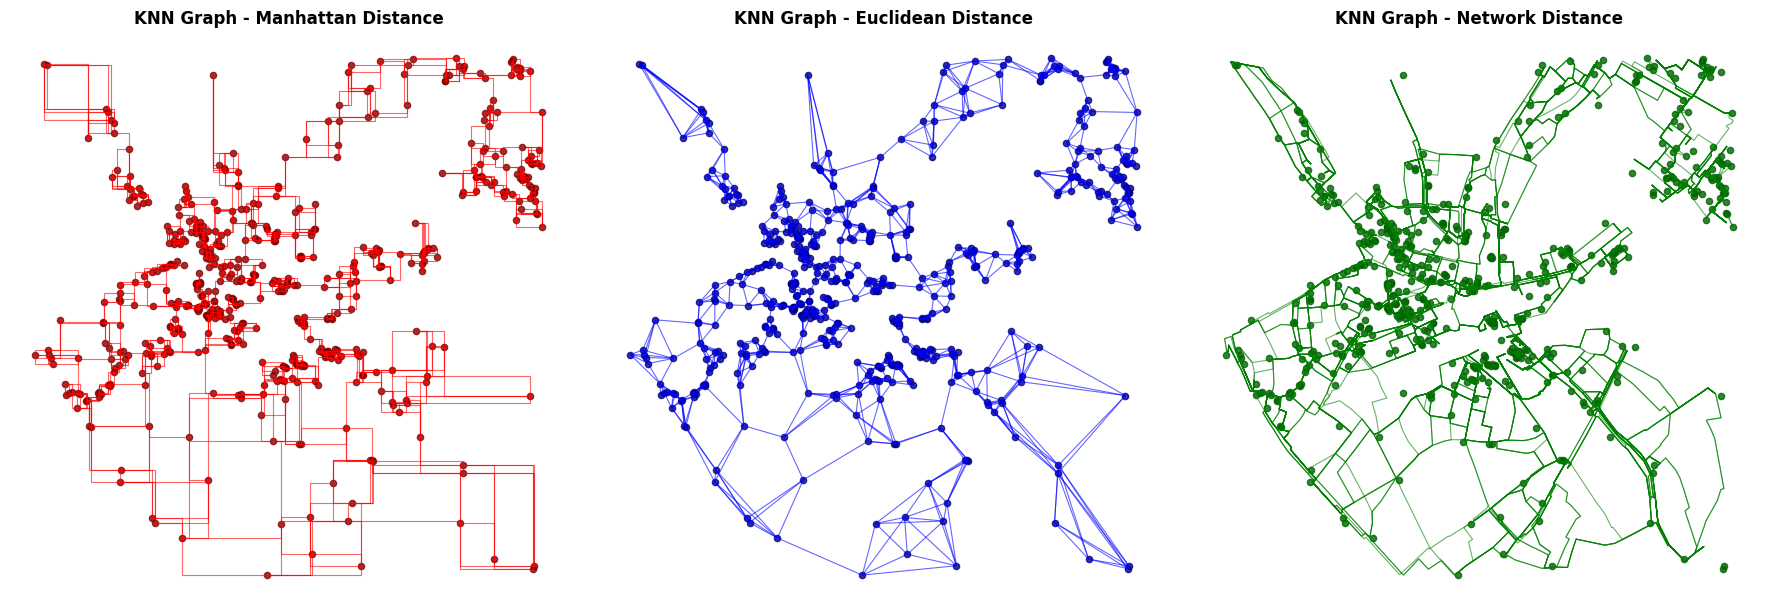

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Manhattan distance KNN graph
knn_l1_edges.plot(ax=axes[0], color='red', alpha=0.6, linewidth=0.8)
poi_gdf.plot(ax=axes[0], color='darkred', markersize=20, alpha=0.8)
# ctx.add_basemap(axes[0], crs=poi_gdf.crs, source=ctx.providers.CartoDB.Positron)
axes[0].set_title('KNN Graph - Manhattan Distance', fontsize=12, fontweight='bold')
axes[0].set_aspect('equal')
axes[0].axis('off')

# Plot Euclidean distance KNN graph
knn_l2_edges.plot(ax=axes[1], color='blue', alpha=0.6, linewidth=0.8)
poi_gdf.plot(ax=axes[1], color='darkblue', markersize=20, alpha=0.8)
# ctx.add_basemap(axes[1], crs=poi_gdf.crs, source=ctx.providers.CartoDB.Positron)
axes[1].set_title('KNN Graph - Euclidean Distance', fontsize=12, fontweight='bold')
axes[1].set_aspect('equal')
axes[1].axis('off')

# Plot Network distance KNN graph
knn_net_edges.plot(ax=axes[2], color='green', alpha=0.6, linewidth=0.8)
poi_gdf.plot(ax=axes[2], color='darkgreen', markersize=20, alpha=0.8)
# ctx.add_basemap(axes[2], crs=poi_gdf.crs, source=ctx.providers.CartoDB.Positron)
axes[2].set_title('KNN Graph - Network Distance', fontsize=12, fontweight='bold')
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.tight_layout()
plt.show()